In [1]:
from pathlib import Path
import sys
import numpy as np

# # Add mast3r repo to path so internal absolute imports work
# # (mast3r uses `from mast3r.xyz import ...` internally)
# MAST3R_REPO_PATH = Path(
#     "/home/hugues/Documents/phd-workspace/projects/reef_change_detection/src/reef_change_detection/mast3r"
# )
# if str(MAST3R_REPO_PATH) not in sys.path:
#     sys.path.insert(0, str(MAST3R_REPO_PATH))

# For notebooks, use a path relative to the project root
PROJECT_ROOT = Path("/home/hugues/Documents/mee-deepreefmap")
MAST3R_REPO_PATH = PROJECT_ROOT / "mast3r"
DUST3R_REPO_PATH = MAST3R_REPO_PATH / "dust3r"

for p in [MAST3R_REPO_PATH, DUST3R_REPO_PATH]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

In [2]:
frames_2022_dir = Path(
    "/home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames"
)
frames_2025_dir = Path(
    "/home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2025/cam1/frames"
)

frames_2025_bw_dir = Path(
    "/home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2025/cam2/frames"
)

frames_makassar_dir = Path(
    "/home/hugues/Documents/phd-workspace/data/change-detection-data/makassar/2025/day1/cam6_johnny/frames"
)

frames_2022 = list(frames_2022_dir.glob("*.jpg"))
frames_2025 = list(frames_2025_dir.glob("*.jpg"))
frames_2025_bw = list(frames_2025_bw_dir.glob("*.jpg"))
frames_makassar = list(frames_makassar_dir.glob("*.jpg"))

print("Found", len(frames_2022), "frames in 2022")
print("Found", len(frames_2025), "frames in 2025")
print("Found", len(frames_2025_bw), "frames in 2025 (Backward transect)")
print("Found", len(frames_makassar), "frames in makassar")


def interpolate_frame_number(frame_vid_1, n_frames_1, n_frames_2):
    return int(np.floor(frame_vid_1 * (n_frames_2 / n_frames_1)))


Found 5050 frames in 2022
Found 2560 frames in 2025
Found 2700 frames in 2025 (Backward transect)
Found 1000 frames in makassar


In [3]:
# Now we can import directly since mast3r repo is on sys.path
from mast3r.model import AsymmetricMASt3R
from mast3r.fast_nn import fast_reciprocal_NNs
import torch

model_name = "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Use from_pretrained to load the model (not the constructor)
model = AsymmetricMASt3R.from_pretrained(model_name).to(device)

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


/home/hugues/Documents/mee-deepreefmap/.venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>> Loading a list of 2 images
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000001.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2025/cam1/frames/GX010582_frame_000011.jpg with resolution 1920x1080 --> 512x288
 (Found 2 images)
>> Inference with model on 1 image pairs


100%|██████████| 1/1 [00:00<00:00,  6.86it/s]


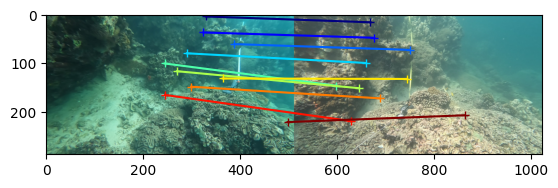

In [5]:
from dust3r.utils.image import load_images
from dust3r.inference import inference
from mast3r.fast_nn import extract_correspondences_nonsym


# load_images expects string paths, not Path objects
images = load_images([str(frames_2022[0]), str(frames_2025[10])], size=512)

output = inference([tuple(images)], model, device, batch_size=1)

# at this stage, you have the raw dust3r predictions
view1, pred1 = output["view1"], output["pred1"]
view2, pred2 = output["view2"], output["pred2"]

desc1, desc2 = pred1["desc"].squeeze(0).detach(), pred2["desc"].squeeze(0).detach()

confidences = [pred1["desc_conf"].squeeze(0).detach(), pred2["desc_conf"].squeeze(0).detach()]

# find 2D-2D matches between the two images
# matches_im0, matches_im1 = fast_reciprocal_NNs(
#     desc1, desc2, subsample_or_initxy1=8, device=device, dist="dot", block_size=2**13
# )

corres = extract_correspondences_nonsym(
    desc1, desc2, confidences[0], confidences[1], device=device, subsample=8, pixel_tol=0
)

conf = corres[2]
mask = conf >= 0.5
matches_im0 = corres[0][mask].cpu().numpy()
matches_im1 = corres[1][mask].cpu().numpy()


# ignore small border around the edge
H0, W0 = view1["true_shape"][0]
valid_matches_im0 = (
    (matches_im0[:, 0] >= 3)
    & (matches_im0[:, 0] < int(W0) - 3)
    & (matches_im0[:, 1] >= 3)
    & (matches_im0[:, 1] < int(H0) - 3)
)

H1, W1 = view2["true_shape"][0]
valid_matches_im1 = (
    (matches_im1[:, 0] >= 3)
    & (matches_im1[:, 0] < int(W1) - 3)
    & (matches_im1[:, 1] >= 3)
    & (matches_im1[:, 1] < int(H1) - 3)
)

valid_matches = valid_matches_im0 & valid_matches_im1
matches_im0, matches_im1 = matches_im0[valid_matches], matches_im1[valid_matches]

# visualize a few matches
import numpy as np
import torch
import torchvision.transforms.functional
from matplotlib import pyplot as pl

n_viz = 10
num_matches = matches_im0.shape[0]
match_idx_to_viz = np.round(np.linspace(0, num_matches - 1, n_viz)).astype(int)
viz_matches_im0, viz_matches_im1 = matches_im0[match_idx_to_viz], matches_im1[match_idx_to_viz]

image_mean = torch.as_tensor([0.5, 0.5, 0.5], device="cpu").reshape(1, 3, 1, 1)
image_std = torch.as_tensor([0.5, 0.5, 0.5], device="cpu").reshape(1, 3, 1, 1)

viz_imgs = []
for i, view in enumerate([view1, view2]):
    rgb_tensor = view["img"] * image_std + image_mean
    viz_imgs.append(rgb_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy())

H0, W0, H1, W1 = *viz_imgs[0].shape[:2], *viz_imgs[1].shape[:2]
img0 = np.pad(viz_imgs[0], ((0, max(H1 - H0, 0)), (0, 0), (0, 0)), "constant", constant_values=0)
img1 = np.pad(viz_imgs[1], ((0, max(H0 - H1, 0)), (0, 0), (0, 0)), "constant", constant_values=0)
img = np.concatenate((img0, img1), axis=1)
pl.figure()
pl.imshow(img)
cmap = pl.get_cmap("jet")
for i in range(n_viz):
    (x0, y0), (x1, y1) = viz_matches_im0[i].T, viz_matches_im1[i].T
    pl.plot([x0, x1 + W0], [y0, y1], "-+", color=cmap(i / (n_viz - 1)), scalex=False, scaley=False)
pl.show(block=True)

## MASt3R → COLMAP Pipeline

**Workflow:**
1. **Load images** - Use `load_images()` to prepare images for MASt3R
2. **Generate pairs** - Use `make_pairs()` with a scene graph strategy:
   - `'swin-5'`: Sliding window (good for video sequences)
   - `'logwin-5'`: Log-spaced window (better for longer sequences)
   - `'complete'`: All pairs (slow, only for <50 images)
3. **Run inference** - Extract dense features and 3D predictions
4. **Extract matches** - Get 2D-2D correspondences from descriptors
5. **Export to COLMAP** - Create database with keypoints and matches
6. **Run reconstruction** - COLMAP incremental mapper or glomap

In [ ]:
# =============================================================================
# MASt3R → COLMAP Pipeline for 100 images
# =============================================================================
# This shows how to extract MASt3R features and export them to COLMAP

import os
import torch
from pathlib import Path
from tqdm import tqdm

from mast3r.model import AsymmetricMASt3R
from mast3r.fast_nn import fast_reciprocal_NNs
from mast3r.image_pairs import make_pairs
from mast3r.colmap.mapping import scene_prepare_images
from dust3r.inference import inference

# 1. Select 100 images (sorted for sequential pairing)
# Use relative paths from a common root directory
image_root = str(frames_2022_dir)
# image_paths = sorted([p.name for p in frames_2022[:100]])  # relative paths

image_paths = [str(frames_2022[0]), str(frames_2022[0])]

print(f"Selected {len(image_paths)} images from {image_root}")

# 2. Load images for MASt3R using scene_prepare_images (includes metadata for COLMAP export)
# Get model parameters for proper image sizing
maxdim = max(model.patch_embed.img_size)  # typically 512
patch_size = model.patch_embed.patch_size  # typically 16

images = scene_prepare_images(image_root, maxdim, patch_size, image_paths)
print(f"Loaded {len(images)} images with shape metadata")

In [ ]:
# 3. Generate image pairs using a scene graph strategy
# For sequential video frames, use sliding window ('swin-N') or log window ('logwin-N')
# - 'complete': all pairs (slow for 100+ images: 4950 pairs!)
# - 'swin-5': sliding window of 5 neighbors (efficient for video)
# - 'logwin-5': log-spaced window (good for longer sequences)
# - 'oneref-0': all images matched to image 0

pairs = make_pairs(images, scene_graph="swin-5", symmetrize=True)
print(f"Generated {len(pairs)} pairs (with symmetrization)")

In [ ]:
# 4. Run MASt3R inference on pairs (in batches)
# This extracts dense features and 3D predictions

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 16  # Adjust based on your GPU memory

all_preds = []
for i in tqdm(range(0, len(pairs), batch_size), desc="Running MASt3R inference"):
    batch_pairs = pairs[i : i + batch_size]
    with torch.no_grad():
        output = inference(batch_pairs, model, device, batch_size=batch_size, verbose=False)
    all_preds.append(output)

print(f"Processed {len(pairs)} pairs")

In [ ]:
# 5. Extract 2D-2D correspondences from MASt3R predictions
# These can be used for COLMAP feature matching

from mast3r.fast_nn import extract_correspondences_nonsym


def extract_matches_from_pred(pred1, pred2, conf_thr=1.5):
    """Extract 2D-2D matches from MASt3R predictions."""
    matches_list = []

    for i in range(len(pred1["pts3d"])):
        descs = [pred1["desc"][i], pred2["desc"][i]]
        confidences = [pred1["desc_conf"][i], pred2["desc_conf"][i]]

        # Extract sparse correspondences using fast reciprocal NN
        corres = extract_correspondences_nonsym(
            descs[0],
            descs[1],
            confidences[0],
            confidences[1],
            device=device,
            subsample=8,
            pixel_tol=0,
        )

        conf = corres[2]
        mask = conf >= conf_thr
        matches_im0 = corres[0][mask].cpu().numpy()
        matches_im1 = corres[1][mask].cpu().numpy()

        matches_list.append({
            "pts0": matches_im0,
            "pts1": matches_im1,
            "conf": conf[mask].cpu().numpy(),
        })

    return matches_list


# Extract matches from first batch as example
if all_preds:
    example_matches = extract_matches_from_pred(all_preds[0]["pred1"], all_preds[0]["pred2"])
    print(f"Example: found {len(example_matches[0]['pts0'])} matches in first pair")

In [ ]:
# 6. Export to COLMAP database
# This creates a COLMAP-compatible database with keypoints and matches

import pycolmap
from mast3r.colmap.database import export_matches, export_images, get_im_matches


def mast3r_to_colmap(image_paths, images, pairs, all_preds, output_dir, image_root, conf_thr=1.5):
    """
    Export MASt3R features to COLMAP database.

    Args:
        image_paths: List of relative image file paths
        images: Loaded images from scene_prepare_images()
        pairs: Image pairs from make_pairs()
        all_preds: MASt3R predictions from inference()
        output_dir: Output directory for COLMAP files
        image_root: Root directory containing images
        conf_thr: Confidence threshold for matches
    """
    from kapture.converter.colmap.database import COLMAPDatabase

    os.makedirs(output_dir, exist_ok=True)
    db_path = os.path.join(output_dir, "colmap.db")

    # Remove existing database
    if os.path.exists(db_path):
        os.remove(db_path)

    # Create COLMAP database
    db = COLMAPDatabase.connect(db_path)
    db.create_tables()

    # Export images and cameras
    image_to_colmap, im_keypoints = export_images(
        db,
        images,
        [img["instance"] for img in images],
        focals=None,  # Let COLMAP estimate
        ga_world_to_cam=None,
        camera_model="SIMPLE_RADIAL",
    )

    # Collect all matches
    im_matches = {}
    pair_idx = 0
    for pred_batch in all_preds:
        batch_matches = get_im_matches(
            pred1=pred_batch["pred1"],
            pred2=pred_batch["pred2"],
            pairs=pairs[pair_idx : pair_idx + len(pred_batch["pred1"]["pts3d"])],
            image_to_colmap=image_to_colmap,
            im_keypoints=im_keypoints,
            conf_thr=conf_thr,
            is_sparse=True,
            pixel_tol=0,
            device=device,
        )
        im_matches.update(batch_matches)
        pair_idx += len(pred_batch["pred1"]["pts3d"])

    # Export matches to database
    colmap_image_pairs = export_matches(
        db,
        images,
        image_to_colmap,
        im_keypoints,
        im_matches,
        min_len_track=3,
        skip_geometric_verification=False,
    )

    db.commit()
    db.close()

    print(f"Created COLMAP database at {db_path}")
    print(f"Exported {len(colmap_image_pairs)} image pairs with matches")

    return db_path, colmap_image_pairs


# Run the export
output_dir = "/home/hugues/Documents/phd-workspace/data/mast3r_colmap_output"
db_path, colmap_pairs = mast3r_to_colmap(
    image_paths, images, pairs, all_preds, output_dir, image_root
)

In [ ]:
# 8. Create pairs.txt and run COLMAP reconstruction
import pycolmap

sparse_dir = os.path.join(output_dir, "sparse")
os.makedirs(sparse_dir, exist_ok=True)

# Create pairs.txt from the matched pairs
pairs_path = os.path.join(output_dir, "pairs.txt")
with open(pairs_path, "w") as f:
    for img1, img2 in colmap_pairs:
        f.write(f"{img1} {img2}\n")
print(f"Created {pairs_path} with {len(colmap_pairs)} pairs")

# Verify matches geometrically (optional but recommended)
print("Verifying matches...")
pycolmap.verify_matches(database_path=db_path, pairs_path=pairs_path)

# Run incremental mapping
print("Running reconstruction...")
reconstructions = pycolmap.incremental_mapping(
    database_path=db_path,
    image_path=image_root,
    output_path=sparse_dir,
)

print(f"\nReconstruction complete!")
print(f"Output saved to: {sparse_dir}")
print(f"\nOpen in COLMAP GUI with:")
print(f"  colmap gui --import_path {sparse_dir}/0")

In [ ]:
import pycolmap

# Run reconstruction
output_dir = "/home/hugues/Documents/phd-workspace/data/mast3r_colmap_output"
sparse_dir = os.path.join(output_dir, "sparse")
os.makedirs(sparse_dir, exist_ok=True)

# Verify matches first
pycolmap.verify_matches(
    database_path=db_path,
    pairs_path=os.path.join(output_dir, "pairs.txt"),  # if you have one
)

# Run incremental mapping
reconstructions = pycolmap.incremental_mapping(
    database_path=db_path,
    image_path=image_root,
    output_path=sparse_dir,
)

print(f"Reconstruction saved to {sparse_dir}")
print(f"Open with: colmap gui --import_path {sparse_dir}/0")

## Frame Retrieval: Find Best Matching Frames

Given a query frame from one time period, find the best matching frames from another time period using MASt3R correspondences.

In [3]:
def find_best_matching_frames(
    query_frame_path,
    candidate_frame_paths,
    model,
    device="cuda",
    top_k=5,
    conf_threshold=1.0,
    batch_size=8,
):
    """
    Find the best matching frames from a candidate set using MASt3R correspondences.

    Args:
        query_frame_path: Path to the query frame (str or Path)
        candidate_frame_paths: List of paths to candidate frames
        model: MASt3R model
        device: Device to run inference on
        top_k: Number of top matches to return
        conf_threshold: Minimum confidence for valid correspondences
        batch_size: Number of candidates to process at once

    Returns:
        List of tuples: [(frame_path, num_matches, avg_confidence), ...]
    """
    from dust3r.utils.image import load_images
    from dust3r.inference import inference
    from mast3r.fast_nn import extract_correspondences_nonsym
    from tqdm import tqdm

    # Load query frame
    query_img = load_images([str(query_frame_path)], size=512)[0]

    results = []

    # Process candidates in batches
    for i in tqdm(range(0, len(candidate_frame_paths), batch_size), desc="Matching frames"):
        batch_paths = candidate_frame_paths[i : i + batch_size]
        batch_imgs = load_images([str(p) for p in batch_paths], size=512)

        # Create pairs with query
        pairs = [(query_img, cand_img) for cand_img in batch_imgs]

        # Run inference
        with torch.no_grad():
            output = inference(pairs, model, device, batch_size=1, verbose=False)

        # Extract correspondences for each pair
        for j, cand_path in enumerate(batch_paths):
            desc_query = output["pred1"]["desc"][j].squeeze(0)
            desc_cand = output["pred2"]["desc"][j].squeeze(0)
            conf_query = output["pred1"]["desc_conf"][j].squeeze(0)
            conf_cand = output["pred2"]["desc_conf"][j].squeeze(0)

            # Get correspondences
            corres = extract_correspondences_nonsym(
                desc_query,
                desc_cand,
                conf_query,
                conf_cand,
                device=device,
                subsample=8,
                pixel_tol=0,
            )

            # Filter by confidence
            conf = corres[2]
            valid_mask = conf >= conf_threshold
            num_matches = valid_mask.sum().item()
            avg_conf = conf[valid_mask].mean().item() if num_matches > 0 else 0.0

            results.append((cand_path, num_matches, avg_conf))

    # Sort by number of matches (descending), then by average confidence
    results.sort(key=lambda x: (x[1], x[2]), reverse=True)

    return results[:top_k]

In [40]:
# Example usage
query_frame = frames_2025[50]
candidate_frames = frames_2022[:1600:10]  # Search in first 100 frames of 2022 with a step of 10

print(f"Query frame: {query_frame.name}")
print(f"Searching in {len(candidate_frames)} candidate frames...\n")

top_matches = find_best_matching_frames(
    query_frame, candidate_frames, model, device=device, top_k=5, conf_threshold=1.0, batch_size=16
)

print("\nTop 5 matching frames:")
for rank, (frame_path, num_matches, avg_conf) in enumerate(top_matches, 1):
    print(f"{rank}. {frame_path.name}")
    print(f"   Matches: {num_matches}, Avg confidence: {avg_conf:.2f}")

Query frame: GX010582_frame_000051.jpg
Searching in 160 candidate frames...

>> Loading a list of 1 images
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2025/cam1/frames/GX010582_frame_000051.jpg with resolution 1920x1080 --> 512x288
 (Found 1 images)


Matching frames:   0%|          | 0/10 [00:00<?, ?it/s]

>> Loading a list of 16 images
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000001.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000011.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000021.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000031.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000041.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-k

Matching frames:  10%|█         | 1/10 [00:04<00:43,  4.86s/it]

>> Loading a list of 16 images
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000161.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000171.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000181.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000191.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000201.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-k

...

>> Loading a list of 16 images
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001281.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001291.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001301.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001311.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001321.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-k

Matching frames:  90%|█████████ | 9/10 [00:42<00:04,  4.75s/it]

>> Loading a list of 16 images
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001441.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001451.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001461.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001471.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_001481.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-k

Matching frames: 100%|██████████| 10/10 [00:47<00:00,  4.75s/it]


Top 5 matching frames:
1. GX010166_frame_000081.jpg
   Matches: 806, Avg confidence: 1.38
2. GX010166_frame_000031.jpg
   Matches: 776, Avg confidence: 1.26
3. GX010166_frame_000021.jpg
   Matches: 722, Avg confidence: 1.28
4. GX010166_frame_000041.jpg
   Matches: 446, Avg confidence: 1.21
5. GX010166_frame_000071.jpg
   Matches: 354, Avg confidence: 1.16


In [ ]:
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

for i, query_frames in tqdm(enumerate(frames_2025[::100]), desc="Processing query frames"):
    top_matches = find_best_matching_frames(
        query_frames,
        candidate_frames,
        model,
        device=device,
        top_k=5,
        conf_threshold=1.0,
        batch_size=16,
    )
    print(f"Top 5 matches for {query_frames.name}:")
    for rank, (frame_path, num_matches, avg_conf) in enumerate(top_matches, 1):
        print(f"{rank}. {frame_path.name}")
        print(f"   Matches: {num_matches}, Avg confidence: {avg_conf:.2f}")

    # Visualize the best match
    best_match_path = top_matches[0][0]
    num_matches = top_matches[0][1]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Query frame
    query_img = Image.open(query_frame)
    axes[0].imshow(query_img)
    axes[0].set_title(f"Query: {query_frame.name}", fontsize=10)
    axes[0].axis("off")

    # Best match
    match_img = Image.open(best_match_path)
    axes[1].imshow(match_img)
    axes[1].set_title(
        f"Best Match: {best_match_path.name}\n{num_matches} correspondences", fontsize=10
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

>> Loading a list of 2 images
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2025/cam1/frames/GX010582_frame_000051.jpg with resolution 1920x1080 --> 512x288
 - adding /home/hugues/Documents/phd-workspace/data/change-detection-data/arta-ras-korali/2022/dive3/cam1/frames/GX010166_frame_000081.jpg with resolution 1920x1080 --> 512x288
 (Found 2 images)


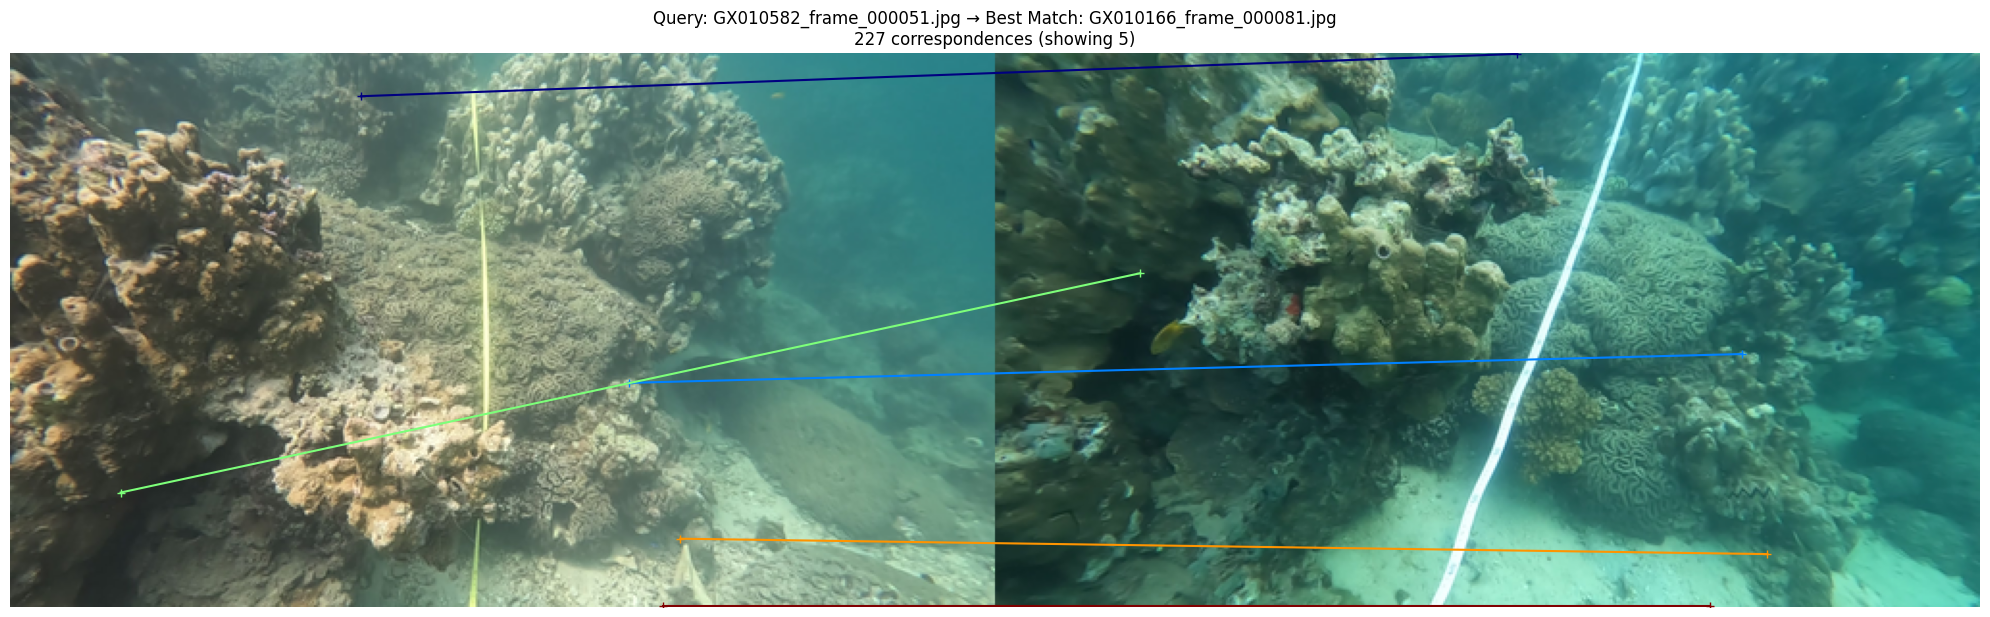

Saved to best_match_correspondences.png


In [46]:
# Visualize correspondences between query and best match (similar to earlier matching viz)
from dust3r.utils.image import load_images
from dust3r.inference import inference
from mast3r.fast_nn import extract_correspondences_nonsym
import matplotlib.pyplot as plt
import numpy as np

best_match_path = top_matches[0][0]

# Run inference on the pair
images = load_images([str(query_frame), str(best_match_path)], size=512)
output = inference([tuple(images)], model, device, batch_size=1, verbose=False)

view1, pred1 = output["view1"], output["pred1"]
view2, pred2 = output["view2"], output["pred2"]

# Extract correspondences
desc1, desc2 = pred1["desc"].squeeze(0).detach(), pred2["desc"].squeeze(0).detach()
conf1, conf2 = pred1["desc_conf"].squeeze(0).detach(), pred2["desc_conf"].squeeze(0).detach()

corres = extract_correspondences_nonsym(
    desc1, desc2, conf1, conf2, device=device, subsample=8, pixel_tol=0
)
conf = corres[2]
mask = conf >= 1.5
matches_im0 = corres[0][mask].cpu().numpy()
matches_im1 = corres[1][mask].cpu().numpy()

# Prepare images for visualization
image_mean = torch.as_tensor([0.5, 0.5, 0.5], device="cpu").reshape(1, 3, 1, 1)
image_std = torch.as_tensor([0.5, 0.5, 0.5], device="cpu").reshape(1, 3, 1, 1)

viz_imgs = []
for view in [view1, view2]:
    rgb_tensor = view["img"] * image_std + image_mean
    viz_imgs.append(rgb_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy())

H0, W0, H1, W1 = *viz_imgs[0].shape[:2], *viz_imgs[1].shape[:2]
img0 = np.pad(viz_imgs[0], ((0, max(H1 - H0, 0)), (0, 0), (0, 0)), "constant", constant_values=0)
img1 = np.pad(viz_imgs[1], ((0, max(H0 - H1, 0)), (0, 0), (0, 0)), "constant", constant_values=0)
img = np.concatenate((img0, img1), axis=1)

# Visualize matches
n_viz = 5
if len(matches_im0) > 100:
    match_idx_to_viz = np.round(np.linspace(0, len(matches_im0) - 1, n_viz)).astype(int)
    viz_matches_im0, viz_matches_im1 = matches_im0[match_idx_to_viz], matches_im1[match_idx_to_viz]

    plt.figure(figsize=(20, 10))
    plt.imshow(img)
    plt.title(
        f"Query: {query_frame.name} → Best Match: {best_match_path.name}\n"
        f"{len(matches_im0)} correspondences (showing {n_viz})",
        fontsize=12,
    )

    cmap = plt.get_cmap("jet")
    for i in range(n_viz):
        (x0, y0), (x1, y1) = viz_matches_im0[i].T, viz_matches_im1[i].T
        plt.plot(
            [x0, x1 + W0],
            [y0, y1],
            "-+",
            color=cmap(i / (n_viz - 1)),
            scalex=False,
            scaley=False,
            linewidth=1.5,
            markersize=6,
        )

    plt.axis("off")
    plt.tight_layout()
    plt.savefig("best_match_correspondences.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to best_match_correspondences.png")
else:
    print("No matches found!")

In [1]:
import open3d as o3d

pcd1 = o3d.io.read_point_cloud(
    "/home/hugues/Documents/mee-deepreefmap/output/output_25_da3/point_cloud_semantic.ply"
)
pcd2 = o3d.io.read_point_cloud(
    "/home/hugues/Documents/mee-deepreefmap/output_25_bw/point_cloud_semantic.ply"
)
merged = pcd1 + pcd2
o3d.io.write_point_cloud("merged.ply", merged)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


True

In [2]:
# show merged point cloud
o3d.visualization.draw_geometries([merged])


[Open3D WARNING] GLFW Error: X11: Failed to open display eceo-ws15:10.0
[Open3D WARNING] Failed to initialize GLFW
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
